# Volatility Investigation — Zurich Datathon 2026

**Core finding from EDA**: 1st-half volatility (σ of bar returns) is *moderately correlated* with 2nd-half |return|.

**What this means**:
- Volatility is *persistent* across sessions: a turbulent first half tends to produce a larger absolute move in the second half.
- This is **not** a direction signal — it tells us the *magnitude* of the 2nd-half move, not its sign.
- Implication: even without knowing direction, we can scale position size by predicted volatility. High-vol sessions where we are right earn more; low-vol sessions where we are wrong lose less.
- This is the classic *volatility targeting / inverse-vol sizing* idea in quantitative finance.

**Investigations in this notebook**:
1. Reproduce & quantify the correlation precisely (Pearson, Spearman, bootstrap CI)
2. Multiple volatility estimators (std, Parkinson, Garman-Klass)
3. Volatility regime analysis — bucket sessions by vol, examine target distributions
4. Volatility persistence — which sub-period of the 1st half is most predictive?
5. Position sizing — inverse-vol sizing Sharpe vs flat sizing
6. Vol vs direction — does volatility predict direction, not just magnitude?

## 1. Imports & Data

In [1]:
import sys
sys.executable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')

DATA = '../data'
bars_seen   = pd.read_parquet(f'{DATA}/bars_seen_train.parquet')
bars_unseen = pd.read_parquet(f'{DATA}/bars_unseen_train.parquet')

for df in [bars_seen, bars_unseen]:
    df.sort_values(['session', 'bar_ix'], inplace=True)
    df.reset_index(drop=True, inplace=True)

bars_seen   = bars_seen.copy()
bars_unseen = bars_unseen.copy()
bars_seen['ret']   = bars_seen.groupby('session')['close'].pct_change()
bars_unseen['ret'] = bars_unseen.groupby('session')['close'].pct_change()

halfway = bars_seen[bars_seen['bar_ix'] == 49][['session','close']].rename(columns={'close':'close_half'})
end     = bars_unseen[bars_unseen['bar_ix'] == 99][['session','close']].rename(columns={'close':'close_end'})
target  = halfway.merge(end, on='session')
target['return_2h'] = target['close_end'] / target['close_half'] - 1
target['direction'] = np.sign(target['return_2h'])

print('Sessions:', bars_seen['session'].nunique())
print('bars_seen:', bars_seen.shape, '  bars_unseen:', bars_unseen.shape)

Sessions: 1000
bars_seen: (50000, 7)   bars_unseen: (50000, 7)


## 2. Reproduce & Quantify the Core Correlation

The EDA scatter (section 5) showed `r ≈ 0.3–0.4` between 1st-half σ and |2nd-half return|.  
Here we nail down the number with proper statistics: Pearson r, Spearman ρ, bootstrap 95% CI, and a regression line.

In [2]:
sess = bars_seen.groupby('session').agg(
    vol_1h      = ('ret', 'std'),
    mean_ret_1h = ('ret', 'mean'),
).reset_index()

vol2 = bars_unseen.groupby('session')['ret'].std().rename('vol_2h').reset_index()
sess = sess.merge(vol2, on='session').merge(target, on='session')
sess['abs_return_2h'] = sess['return_2h'].abs()

# 1st-half full return for direction
open_0  = bars_seen[bars_seen['bar_ix'] == 0][['session','open']].set_index('session')['open']
close_49= bars_seen[bars_seen['bar_ix'] == 49][['session','close']].set_index('session')['close']
sess['return_1h'] = (close_49 / open_0 - 1).values
sess['dir_1h']    = np.sign(sess['return_1h'])

r_pearson,  p_pearson  = stats.pearsonr(sess['vol_1h'], sess['abs_return_2h'])
r_spearman, p_spearman = stats.spearmanr(sess['vol_1h'], sess['abs_return_2h'])

rng = np.random.default_rng(42)
boot_r = [
    np.corrcoef(
        sess['vol_1h'].values[idx := rng.choice(len(sess), len(sess), replace=True)],
        sess['abs_return_2h'].values[idx]
    )[0, 1]
    for _ in range(5000)
]
ci_lo, ci_hi = np.percentile(boot_r, [2.5, 97.5])

r_vp, p_vp = stats.pearsonr(sess['vol_1h'], sess['vol_2h'])

print(f'Pearson  r(vol_1h, |ret_2h|) = {r_pearson:.4f}  (p={p_pearson:.2e})')
print(f'Spearman r(vol_1h, |ret_2h|) = {r_spearman:.4f}  (p={p_spearman:.2e})')
print(f'Bootstrap 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'\nVol persistence r(vol_1h, vol_2h) = {r_vp:.4f}  (p={p_vp:.2e})')

Pearson  r(vol_1h, |ret_2h|) = 0.2157  (p=5.41e-12)
Spearman r(vol_1h, |ret_2h|) = 0.2041  (p=7.36e-11)
Bootstrap 95% CI: [0.1604, 0.2702]

Vol persistence r(vol_1h, vol_2h) = 0.7452  (p=7.82e-178)


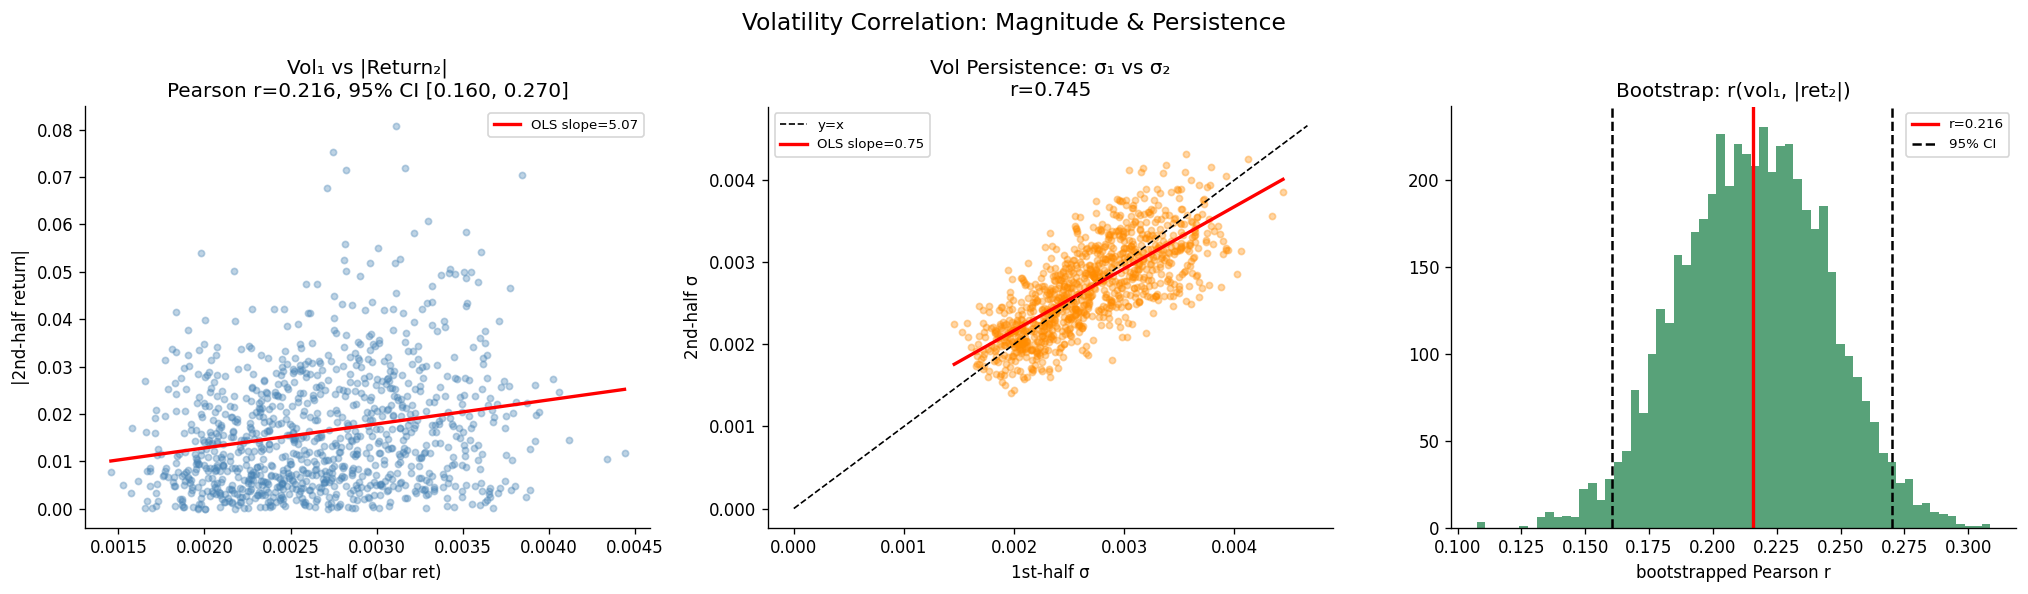

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# scatter: vol_1h vs |ret_2h|
axes[0].scatter(sess['vol_1h'], sess['abs_return_2h'], alpha=0.35, s=14, color='steelblue')
m, b = np.polyfit(sess['vol_1h'], sess['abs_return_2h'], 1)
x_fit = np.linspace(sess['vol_1h'].min(), sess['vol_1h'].max(), 100)
axes[0].plot(x_fit, m*x_fit + b, 'r-', lw=2, label=f'OLS slope={m:.2f}')
axes[0].set_xlabel('1st-half σ(bar ret)')
axes[0].set_ylabel('|2nd-half return|')
axes[0].set_title(f'Vol₁ vs |Return₂|\nPearson r={r_pearson:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
axes[0].legend(fontsize=8)

# scatter: vol_1h vs vol_2h (persistence)
axes[1].scatter(sess['vol_1h'], sess['vol_2h'], alpha=0.35, s=14, color='darkorange')
lim = sess[['vol_1h','vol_2h']].max().max() * 1.05
axes[1].plot([0, lim], [0, lim], 'k--', lw=1, label='y=x')
m2, b2 = np.polyfit(sess['vol_1h'], sess['vol_2h'], 1)
axes[1].plot(x_fit, m2*x_fit + b2, 'r-', lw=2, label=f'OLS slope={m2:.2f}')
axes[1].set_xlabel('1st-half σ'); axes[1].set_ylabel('2nd-half σ')
axes[1].set_title(f'Vol Persistence: σ₁ vs σ₂\nr={r_vp:.3f}')
axes[1].legend(fontsize=8)

# bootstrap dist
axes[2].hist(boot_r, bins=60, color='seagreen', alpha=0.8, edgecolor='none')
axes[2].axvline(r_pearson, color='r', lw=2, label=f'r={r_pearson:.3f}')
axes[2].axvline(ci_lo, color='k', lw=1.5, linestyle='--', label='95% CI')
axes[2].axvline(ci_hi, color='k', lw=1.5, linestyle='--')
axes[2].set_xlabel('bootstrapped Pearson r')
axes[2].set_title('Bootstrap: r(vol₁, |ret₂|)')
axes[2].legend(fontsize=8)

plt.suptitle('Volatility Correlation: Magnitude & Persistence', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Multiple Volatility Estimators

The EDA used `std(bar returns)` (close-to-close). Two OHLC-based estimators use more price information:

- **Parkinson (PK)**: `σ_PK = sqrt( mean(ln(H/L)²) / (4·ln2) )` — uses H-L range, ~5× more efficient than CC under Brownian motion
- **Garman-Klass (GK)**: `σ_GK = sqrt( mean(0.5·(ln H/L)² − (2ln2−1)·(ln C/O)²) )` — most efficient classic estimator, uses full OHLC

Which estimator is most predictive of |return_2h|?

In [4]:
def parkinson_vol(grp):
    log_hl = np.log(grp['high'] / grp['low'])
    return np.sqrt((log_hl**2).mean() / (4 * np.log(2)))

def garman_klass_vol(grp):
    log_hl = np.log(grp['high'] / grp['low'])
    log_co = np.log(grp['close'] / grp['open'])
    return np.sqrt((0.5 * log_hl**2 - (2*np.log(2) - 1) * log_co**2).mean())

vol_df = bars_seen.groupby('session').apply(
    lambda g: pd.Series({
        'vol_cc': g['ret'].std(),
        'vol_pk': parkinson_vol(g),
        'vol_gk': garman_klass_vol(g),
    })
).reset_index()

vol_df = vol_df.merge(target[['session','return_2h']], on='session')
vol_df['abs_r2h'] = vol_df['return_2h'].abs()

print('Estimator correlations with |return_2h|:')
for col, label in [('vol_cc','Close-to-close'), ('vol_pk','Parkinson    '), ('vol_gk','Garman-Klass ')]:
    rp, _ = stats.pearsonr(vol_df[col], vol_df['abs_r2h'])
    rs, _ = stats.spearmanr(vol_df[col], vol_df['abs_r2h'])
    print(f'  {label}  Pearson r={rp:.4f}   Spearman r={rs:.4f}')

print('\nPairwise correlations between estimators:')
print(vol_df[['vol_cc','vol_pk','vol_gk']].corr().round(4))

Estimator correlations with |return_2h|:
  Close-to-close  Pearson r=0.2157   Spearman r=0.2041
  Parkinson      Pearson r=0.2473   Spearman r=0.2245
  Garman-Klass   Pearson r=0.2516   Spearman r=0.2261

Pairwise correlations between estimators:
        vol_cc  vol_pk  vol_gk
vol_cc  1.0000  0.9428  0.8754
vol_pk  0.9428  1.0000  0.9850
vol_gk  0.8754  0.9850  1.0000


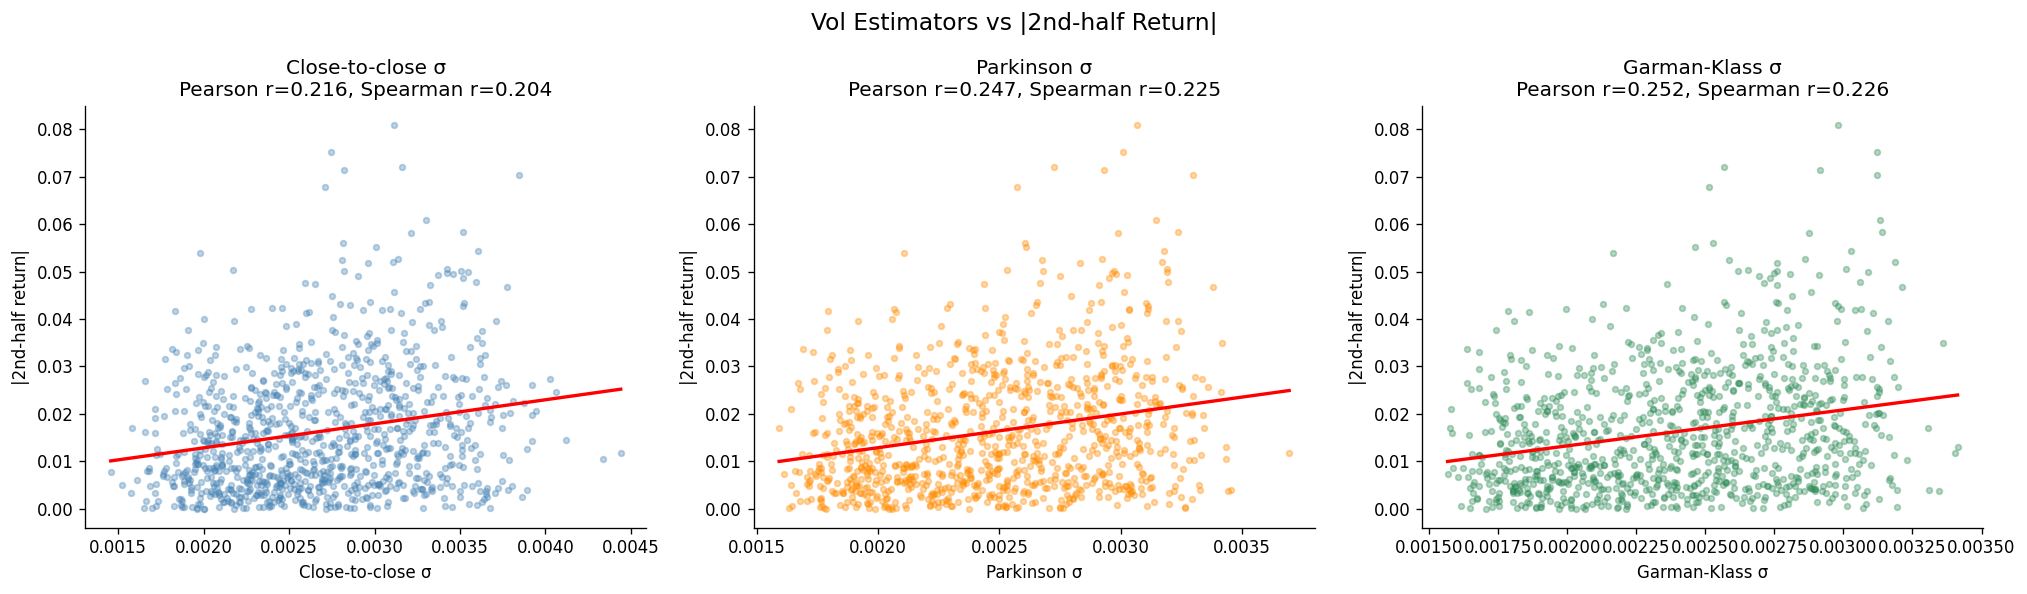

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
estimators = [
    ('vol_cc', 'Close-to-close σ', 'steelblue'),
    ('vol_pk', 'Parkinson σ',      'darkorange'),
    ('vol_gk', 'Garman-Klass σ',   'seagreen'),
]
for ax, (col, label, color) in zip(axes, estimators):
    rp, _ = stats.pearsonr(vol_df[col], vol_df['abs_r2h'])
    rs, _ = stats.spearmanr(vol_df[col], vol_df['abs_r2h'])
    ax.scatter(vol_df[col], vol_df['abs_r2h'], alpha=0.35, s=12, color=color)
    m, b = np.polyfit(vol_df[col], vol_df['abs_r2h'], 1)
    x_fit = np.linspace(vol_df[col].min(), vol_df[col].max(), 100)
    ax.plot(x_fit, m*x_fit + b, 'r-', lw=2)
    ax.set_xlabel(label); ax.set_ylabel('|2nd-half return|')
    ax.set_title(f'{label}\nPearson r={rp:.3f}, Spearman r={rs:.3f}')

plt.suptitle('Vol Estimators vs |2nd-half Return|', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Volatility Regime Analysis

Bucket sessions into vol terciles (Low / Medium / High) and examine the 2nd-half return distribution per regime.

In [6]:
sess['vol_regime'] = pd.qcut(sess['vol_1h'], q=3, labels=['Low','Medium','High'])

summary = sess.groupby('vol_regime').agg(
    n             = ('session',       'count'),
    vol_mean      = ('vol_1h',        'mean'),
    abs_r2h_mean  = ('abs_return_2h', 'mean'),
    abs_r2h_std   = ('abs_return_2h', 'std'),
    pct_up        = ('direction',     lambda x: (x > 0).mean()),
    pct_large     = ('abs_return_2h', lambda x: (x > 0.02).mean()),
).round(4)
print(summary.to_string())

              n  vol_mean  abs_r2h_mean  abs_r2h_std  pct_up  pct_large
vol_regime                                                             
Low         334    0.0021        0.0128       0.0100  0.5210     0.2275
Medium      333    0.0026        0.0163       0.0130  0.6036     0.3363
High        333    0.0033        0.0196       0.0144  0.5856     0.4354


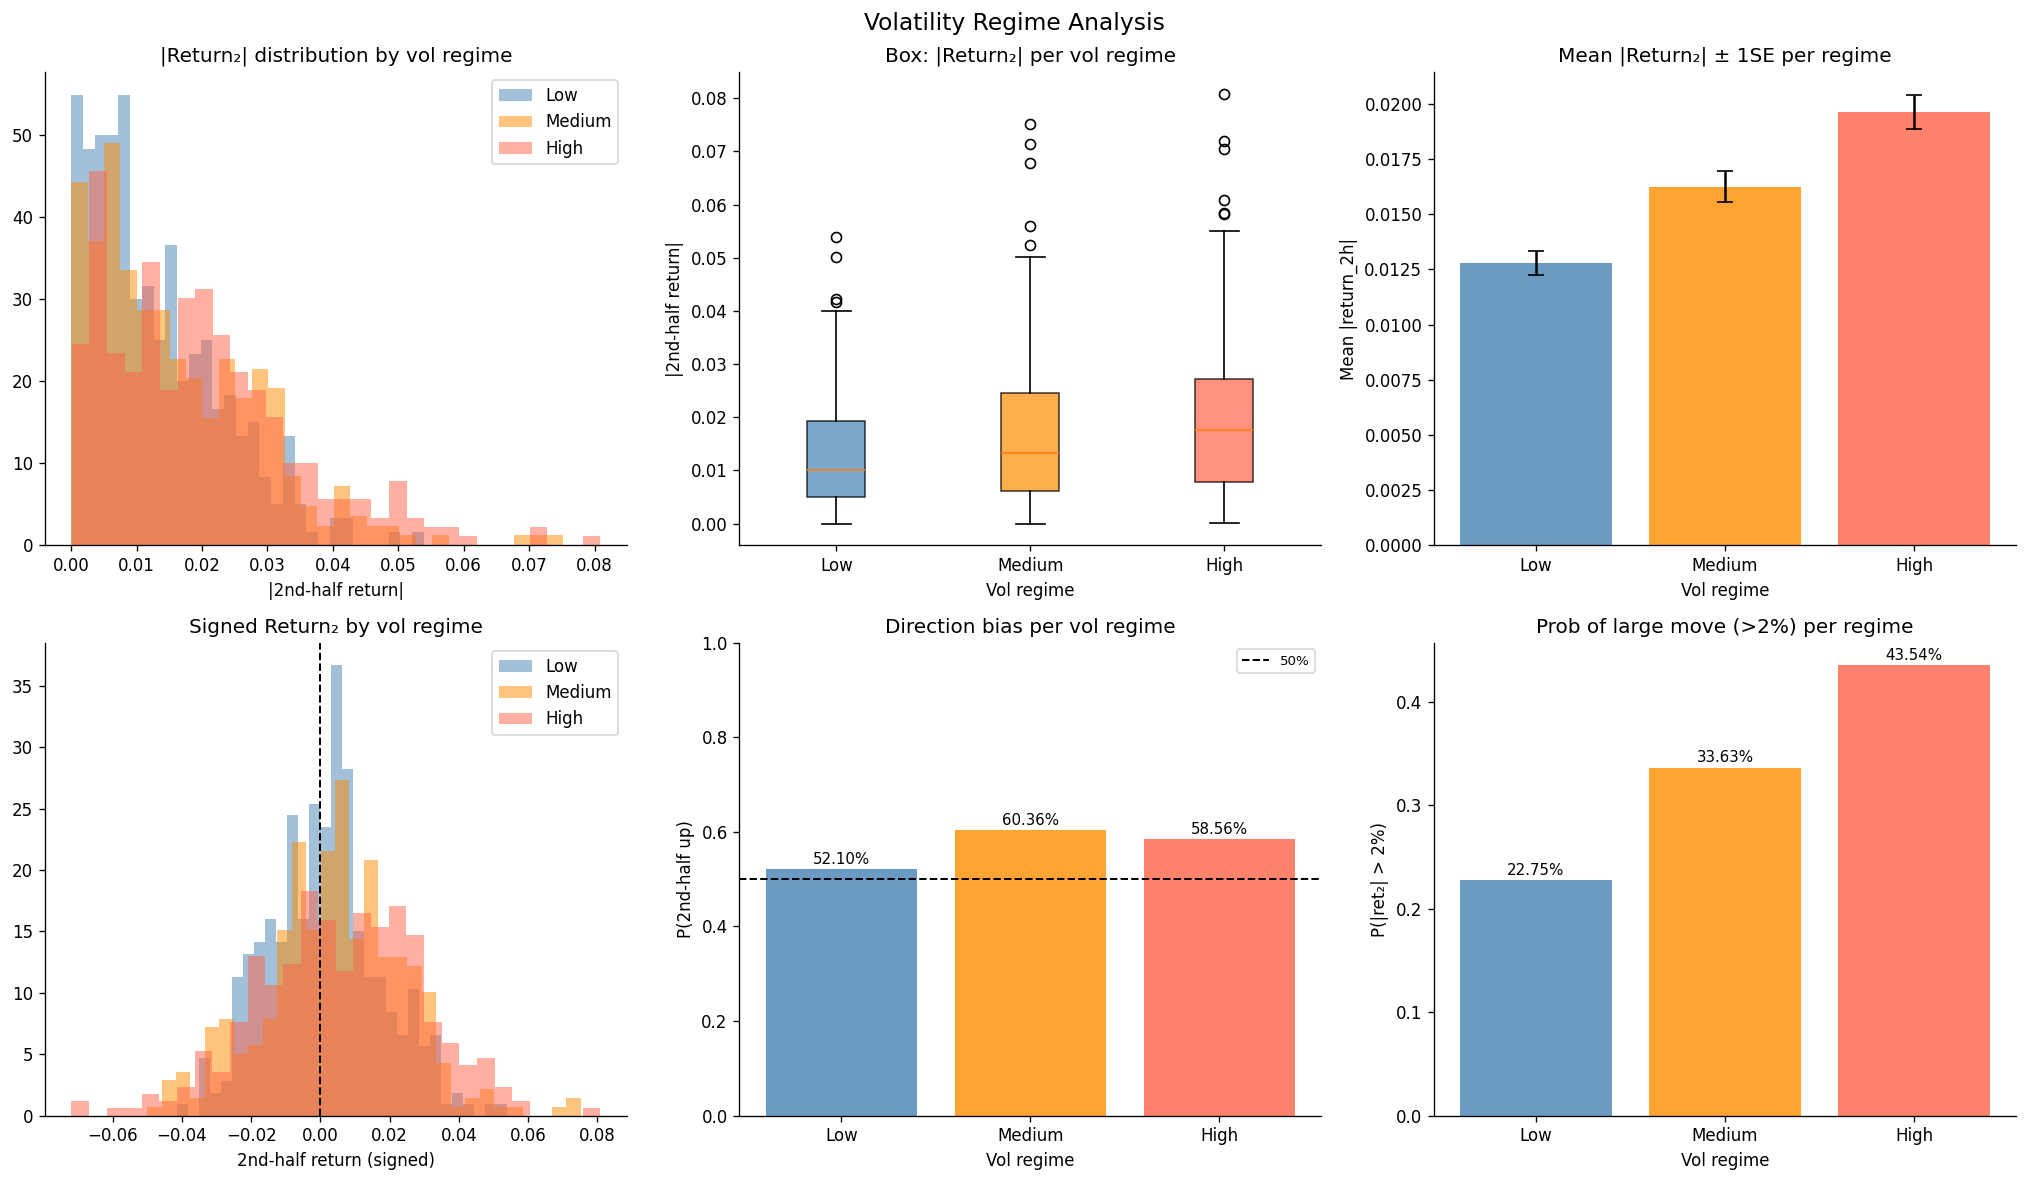

In [7]:
colors_list = ['steelblue', 'darkorange', 'tomato']
palette     = {'Low': 'steelblue', 'Medium': 'darkorange', 'High': 'tomato'}

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# 1. |return_2h| density per regime
for regime, color in palette.items():
    sub = sess[sess['vol_regime'] == regime]['abs_return_2h']
    axes[0, 0].hist(sub, bins=30, alpha=0.5, density=True, color=color, label=regime)
axes[0, 0].set_xlabel('|2nd-half return|')
axes[0, 0].set_title('|Return₂| distribution by vol regime'); axes[0, 0].legend()

# 2. Box plot
data_box = [sess[sess['vol_regime'] == r]['abs_return_2h'].values for r in ['Low','Medium','High']]
bp = axes[0, 1].boxplot(data_box, labels=['Low','Medium','High'], patch_artist=True)
for patch, c in zip(bp['boxes'], colors_list): patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0, 1].set_xlabel('Vol regime'); axes[0, 1].set_ylabel('|2nd-half return|')
axes[0, 1].set_title('Box: |Return₂| per vol regime')

# 3. Mean ± 1SE
grp   = sess.groupby('vol_regime')['abs_return_2h']
means = grp.mean(); ses = grp.std() / np.sqrt(grp.count())
axes[0, 2].bar(means.index, means.values, color=colors_list, alpha=0.8)
axes[0, 2].errorbar(means.index, means.values, yerr=ses.values, fmt='none', color='k', capsize=5, lw=1.5)
axes[0, 2].set_xlabel('Vol regime'); axes[0, 2].set_ylabel('Mean |return_2h|')
axes[0, 2].set_title('Mean |Return₂| ± 1SE per regime')

# 4. Signed return_2h per regime
for regime, color in palette.items():
    sub = sess[sess['vol_regime'] == regime]['return_2h']
    axes[1, 0].hist(sub, bins=30, alpha=0.5, density=True, color=color, label=regime)
axes[1, 0].axvline(0, color='k', lw=1.2, linestyle='--')
axes[1, 0].set_xlabel('2nd-half return (signed)')
axes[1, 0].set_title('Signed Return₂ by vol regime'); axes[1, 0].legend()

# 5. P(up) per regime
pct_up = sess.groupby('vol_regime').apply(lambda g: (g['direction'] > 0).mean())
bars_b = axes[1, 1].bar(pct_up.index, pct_up.values, color=colors_list, alpha=0.8)
axes[1, 1].axhline(0.5, color='k', linestyle='--', lw=1.2, label='50%')
axes[1, 1].set_ylim(0, 1); axes[1, 1].set_xlabel('Vol regime')
axes[1, 1].set_ylabel('P(2nd-half up)'); axes[1, 1].set_title('Direction bias per vol regime')
axes[1, 1].legend(fontsize=8)
for bar, v in zip(bars_b, pct_up.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2%}', ha='center', fontsize=9)

# 6. P(|ret| > 2%) per regime
pct_lg = sess.groupby('vol_regime').apply(lambda g: (g['abs_return_2h'] > 0.02).mean())
bars_c = axes[1, 2].bar(pct_lg.index, pct_lg.values, color=colors_list, alpha=0.8)
axes[1, 2].set_xlabel('Vol regime'); axes[1, 2].set_ylabel('P(|ret₂| > 2%)')
axes[1, 2].set_title('Prob of large move (>2%) per regime')
for bar, v in zip(bars_c, pct_lg.values):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.2%}', ha='center', fontsize=9)

plt.suptitle('Volatility Regime Analysis', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Which Sub-Period of the 1st Half Is Most Predictive?

Does *recent* volatility (last 10 bars) predict the 2nd half better than early volatility or the full 50-bar average?  
We scan window sizes for both last-N-bar and first-N-bar windows.

In [8]:
windows = [5, 10, 15, 20, 25, 30, 40, 50]
rec_rows, early_rows = [], []

for w in windows:
    # Last-N bars
    sub = bars_seen[bars_seen['bar_ix'] >= (49 - w + 1)]
    vw  = sub.groupby('session')['ret'].std().rename('v').reset_index().merge(target[['session','return_2h']], on='session')
    vw['abs_r2h'] = vw['return_2h'].abs()
    rp, _ = stats.pearsonr(vw['v'], vw['abs_r2h'])
    rs, _ = stats.spearmanr(vw['v'], vw['abs_r2h'])
    rec_rows.append({'window': w, 'pearson_r': rp, 'spearman_r': rs})

    # First-N bars
    sub2 = bars_seen[bars_seen['bar_ix'] < w]
    vw2  = sub2.groupby('session')['ret'].std().rename('v').reset_index().merge(target[['session','return_2h']], on='session')
    vw2['abs_r2h'] = vw2['return_2h'].abs()
    mask = vw2['v'].notna()
    rp2, _ = stats.pearsonr(vw2.loc[mask,'v'], vw2.loc[mask,'abs_r2h'])
    rs2, _ = stats.spearmanr(vw2.loc[mask,'v'], vw2.loc[mask,'abs_r2h'])
    early_rows.append({'window': w, 'pearson_r': rp2, 'spearman_r': rs2})

rec_df   = pd.DataFrame(rec_rows)
early_df = pd.DataFrame(early_rows)

print('=== Last-N-bar vol vs |return_2h| ===')
print(rec_df.to_string(index=False))
print('\n=== First-N-bar vol vs |return_2h| ===')
print(early_df.to_string(index=False))

=== Last-N-bar vol vs |return_2h| ===
 window  pearson_r  spearman_r
      5   0.031634    0.037978
     10   0.097121    0.090509
     15   0.130322    0.109094
     20   0.149126    0.126041
     25   0.166131    0.151202
     30   0.172319    0.156937
     40   0.201769    0.193230
     50   0.215716    0.204051

=== First-N-bar vol vs |return_2h| ===
 window  pearson_r  spearman_r
      5   0.101406    0.084434
     10   0.162905    0.151344
     15   0.208747    0.198811
     20   0.216216    0.215035
     25   0.213534    0.215432
     30   0.219751    0.220725
     40   0.221209    0.212249
     50   0.215716    0.204051


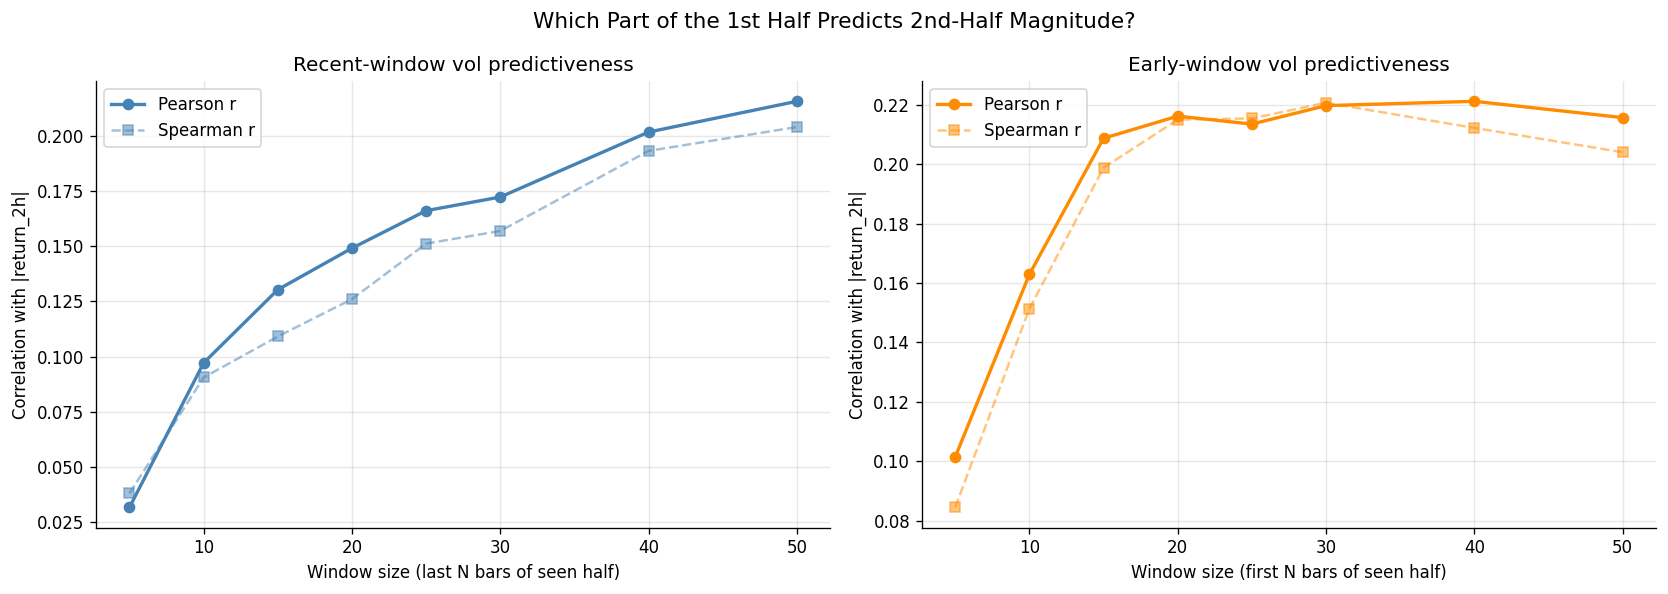

Best recent window: last 50 bars, Pearson r=0.2157


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_df['window'],   rec_df['pearson_r'],   'o-', color='steelblue',  lw=2, label='Pearson r')
axes[0].plot(rec_df['window'],   rec_df['spearman_r'],  's--', color='steelblue', alpha=0.5, label='Spearman r')
axes[0].set_xlabel('Window size (last N bars of seen half)')
axes[0].set_ylabel('Correlation with |return_2h|')
axes[0].set_title('Recent-window vol predictiveness'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(early_df['window'], early_df['pearson_r'],  'o-', color='darkorange', lw=2, label='Pearson r')
axes[1].plot(early_df['window'], early_df['spearman_r'], 's--', color='darkorange', alpha=0.5, label='Spearman r')
axes[1].set_xlabel('Window size (first N bars of seen half)')
axes[1].set_ylabel('Correlation with |return_2h|')
axes[1].set_title('Early-window vol predictiveness'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Which Part of the 1st Half Predicts 2nd-Half Magnitude?', fontsize=13)
plt.tight_layout()
plt.show()

best = rec_df.loc[rec_df['pearson_r'].idxmax()]
print(f'Best recent window: last {int(best["window"])} bars, Pearson r={best["pearson_r"]:.4f}')

## 6. Intraday Volatility Structure

Does volatility change systematically across bar_ix within the seen half?  
And is there an ARCH effect — does high |return| at bar t predict high |return| at bar t+1?

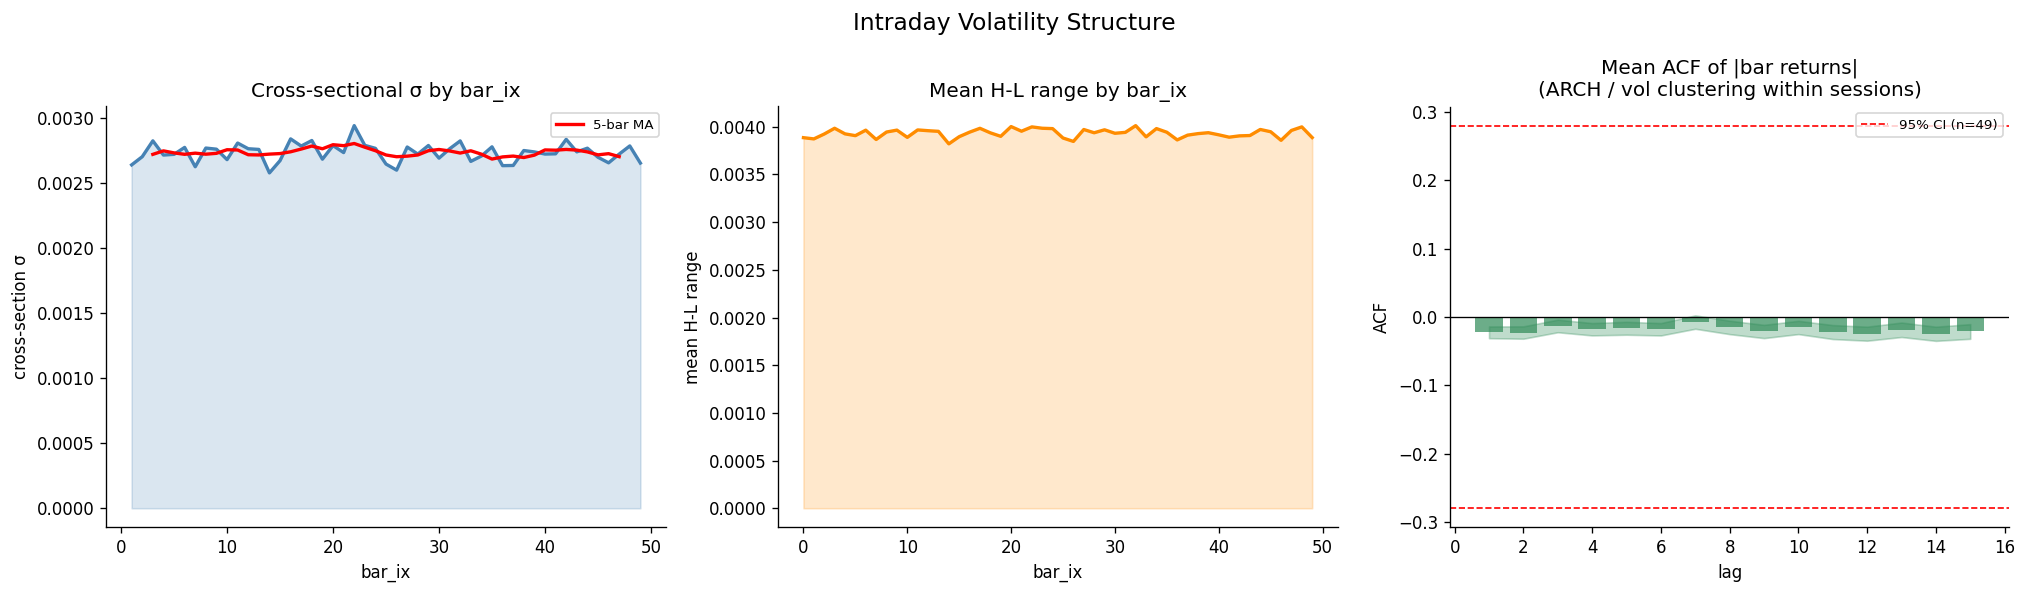

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Cross-sectional σ by bar_ix
vol_by_bar = bars_seen.groupby('bar_ix')['ret'].std()
axes[0].plot(vol_by_bar.index, vol_by_bar.values, color='steelblue', lw=2)
axes[0].fill_between(vol_by_bar.index, vol_by_bar.values, alpha=0.2, color='steelblue')
axes[0].plot(vol_by_bar.rolling(5, center=True).mean().index,
             vol_by_bar.rolling(5, center=True).mean().values, 'r-', lw=2, label='5-bar MA')
axes[0].set_xlabel('bar_ix'); axes[0].set_ylabel('cross-section σ')
axes[0].set_title('Cross-sectional σ by bar_ix'); axes[0].legend(fontsize=8)

# Mean H-L range by bar_ix
hl_by_bar = bars_seen.groupby('bar_ix').apply(lambda g: (g['high'] - g['low']).mean())
axes[1].plot(hl_by_bar.index, hl_by_bar.values, color='darkorange', lw=2)
axes[1].fill_between(hl_by_bar.index, hl_by_bar.values, alpha=0.2, color='darkorange')
axes[1].set_xlabel('bar_ix'); axes[1].set_ylabel('mean H-L range')
axes[1].set_title('Mean H-L range by bar_ix')

# ARCH effect: ACF of |returns| within sessions
max_lag = 15
acf_abs = np.zeros((1000, max_lag))
for i, (_, grp) in enumerate(bars_seen.groupby('session')):
    r = grp['ret'].dropna().abs().values
    for lag in range(1, max_lag + 1):
        if len(r) > lag:
            acf_abs[i, lag-1] = np.corrcoef(r[:-lag], r[lag:])[0, 1]

mean_acf = acf_abs.mean(axis=0)
se_acf   = acf_abs.std(axis=0) / np.sqrt(1000)
lags = np.arange(1, max_lag+1)
axes[2].bar(lags, mean_acf, color='seagreen', alpha=0.7)
axes[2].fill_between(lags, mean_acf - 2*se_acf, mean_acf + 2*se_acf, alpha=0.3, color='seagreen')
axes[2].axhline(0, color='k', lw=0.8)
axes[2].axhline( 1.96/np.sqrt(49), color='r', linestyle='--', lw=1, label='95% CI (n=49)')
axes[2].axhline(-1.96/np.sqrt(49), color='r', linestyle='--', lw=1)
axes[2].set_xlabel('lag'); axes[2].set_ylabel('ACF')
axes[2].set_title('Mean ACF of |bar returns|\n(ARCH / vol clustering within sessions)')
axes[2].legend(fontsize=8)

plt.suptitle('Intraday Volatility Structure', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Does Volatility Predict Direction?

Volatility predicts *magnitude*, but does it also carry a *direction* signal?  
- If high-vol sessions tend to go up (or down), vol would be a direction feature too.
- We check `r(vol_1h, signed_return_2h)` and direction balance per regime.

In [11]:
r_signed, p_signed = stats.pearsonr(sess['vol_1h'], sess['return_2h'])
print(f'r(vol_1h, return_2h [signed]) = {r_signed:.4f}  (p={p_signed:.3f})')
print('→ Near zero: vol does NOT predict direction.')

# Conditional: E[return_2h | vol_regime, dir_1h]
cond = sess.groupby(['vol_regime','dir_1h'])['return_2h'].agg(['mean','std','count']).round(4)
print('\nConditional E[return_2h | vol_regime, dir_1h]:')
print(cond.to_string())

r(vol_1h, return_2h [signed]) = 0.0716  (p=0.023)
→ Near zero: vol does NOT predict direction.

Conditional E[return_2h | vol_regime, dir_1h]:
                     mean     std  count
vol_regime dir_1h                       
Low        -1.0    0.0029  0.0160    149
            0.0       NaN     NaN      0
            1.0   -0.0005  0.0163    185
Medium     -1.0    0.0047  0.0213    161
            0.0    0.0049  0.0136      3
            1.0    0.0035  0.0198    169
High       -1.0    0.0048  0.0258    139
            0.0       NaN     NaN      0
            1.0    0.0059  0.0222    194


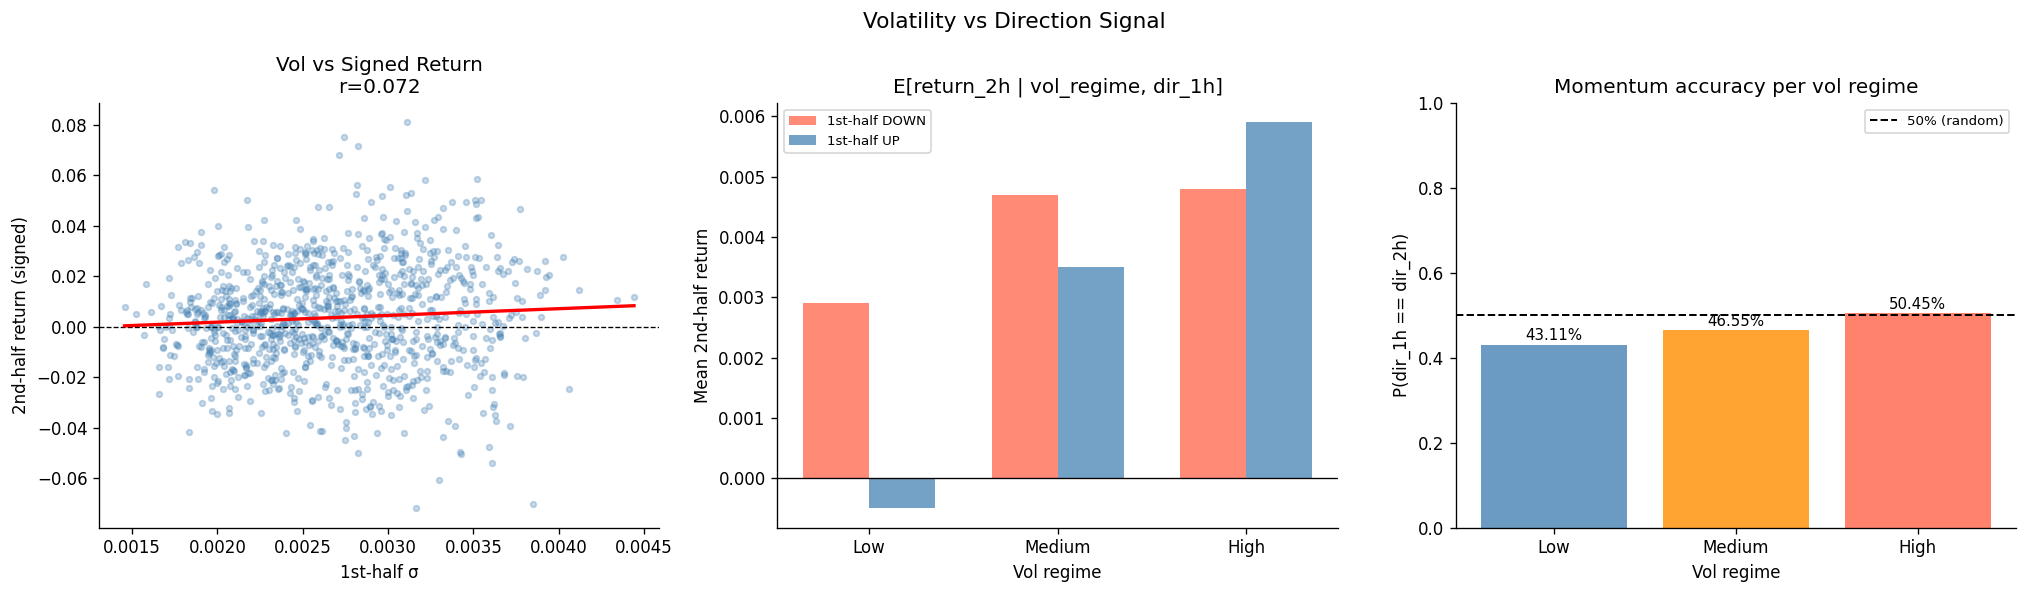

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. vol_1h vs signed return_2h
axes[0].scatter(sess['vol_1h'], sess['return_2h'], alpha=0.3, s=12, color='steelblue')
axes[0].axhline(0, color='k', lw=0.8, linestyle='--')
m_s, b_s = np.polyfit(sess['vol_1h'], sess['return_2h'], 1)
x_f = np.linspace(sess['vol_1h'].min(), sess['vol_1h'].max(), 100)
axes[0].plot(x_f, m_s*x_f + b_s, 'r-', lw=2)
axes[0].set_xlabel('1st-half σ'); axes[0].set_ylabel('2nd-half return (signed)')
axes[0].set_title(f'Vol vs Signed Return\nr={r_signed:.3f}')

# 2. Conditional mean return by vol regime and dir_1h
regimes = ['Low', 'Medium', 'High']
cond_r = cond.reset_index()
x = np.arange(len(regimes))
width = 0.35
for i, (dir_val, color, label) in enumerate([(-1.0,'tomato','1st-half DOWN'), (1.0,'steelblue','1st-half UP')]):
    sub = cond_r[cond_r['dir_1h'] == dir_val].set_index('vol_regime')['mean']
    vals = [sub.get(r, np.nan) for r in regimes]
    axes[1].bar(x + (i-0.5)*width, vals, width, color=color, alpha=0.75, label=label)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(regimes)
axes[1].set_xlabel('Vol regime'); axes[1].set_ylabel('Mean 2nd-half return')
axes[1].set_title('E[return_2h | vol_regime, dir_1h]'); axes[1].legend(fontsize=8)

# 3. P(momentum correct) per vol regime
sess['dir_match'] = (sess['dir_1h'] == sess['direction']).astype(int)
dir_acc = sess.groupby('vol_regime')['dir_match'].mean()
bars3 = axes[2].bar(dir_acc.index, dir_acc.values, color=colors_list, alpha=0.8)
axes[2].axhline(0.5, color='k', linestyle='--', lw=1.2, label='50% (random)')
axes[2].set_ylim(0, 1); axes[2].set_xlabel('Vol regime')
axes[2].set_ylabel('P(dir_1h == dir_2h)')
axes[2].set_title('Momentum accuracy per vol regime'); axes[2].legend(fontsize=8)
for bar, v in zip(bars3, dir_acc.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2%}', ha='center', fontsize=9)

plt.suptitle('Volatility vs Direction Signal', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Position Sizing: Inverse-Vol Strategy

Since vol predicts *magnitude*, we size positions inversely proportional to volatility:  
`size = 1 / vol_1h`, normalised so mean size = 1.

We compare flat sizing vs inverse-vol sizing across three direction strategies  
(always long, momentum, oracle) and study the effect of capping extreme sizes.

In [13]:
def sharpe(positions, returns, scale=16):
    pnl = np.asarray(positions, dtype=float) * np.asarray(returns, dtype=float)
    return (pnl.mean() / pnl.std() * scale) if pnl.std() > 0 else 0.0

r2h  = sess['return_2h'].values
vol  = sess['vol_1h'].values
dir2h = sess['direction'].values
dir1h = sess['dir_1h'].values

inv_vol      = 1.0 / vol
inv_vol_norm = inv_vol / inv_vol.mean()
inv_vol_cap  = np.clip(inv_vol_norm, 0, 2)

strategies = {
    'Always long, flat':             np.ones(1000),
    'Always long, inv-vol':          inv_vol_norm,
    'Always long, inv-vol (cap 2x)': inv_vol_cap,
    'Momentum, flat':                dir1h,
    'Momentum, inv-vol':             dir1h * inv_vol_norm,
    'Momentum, inv-vol (cap 2x)':    dir1h * inv_vol_cap,
    'Oracle, flat':                  dir2h,
    'Oracle, inv-vol':               dir2h * inv_vol_norm,
    'Oracle, inv-vol (cap 2x)':      dir2h * inv_vol_cap,
}

sharpe_s = pd.Series({k: sharpe(v, r2h) for k, v in strategies.items()}).sort_values()
print(sharpe_s.round(4).to_string())

Momentum, inv-vol                -0.3680
Momentum, inv-vol (cap 2x)       -0.3680
Momentum, flat                   -0.1785
Always long, inv-vol              2.6266
Always long, inv-vol (cap 2x)     2.6266
Always long, flat                 2.7661
Oracle, flat                     20.1423
Oracle, inv-vol                  20.7134
Oracle, inv-vol (cap 2x)         20.7134


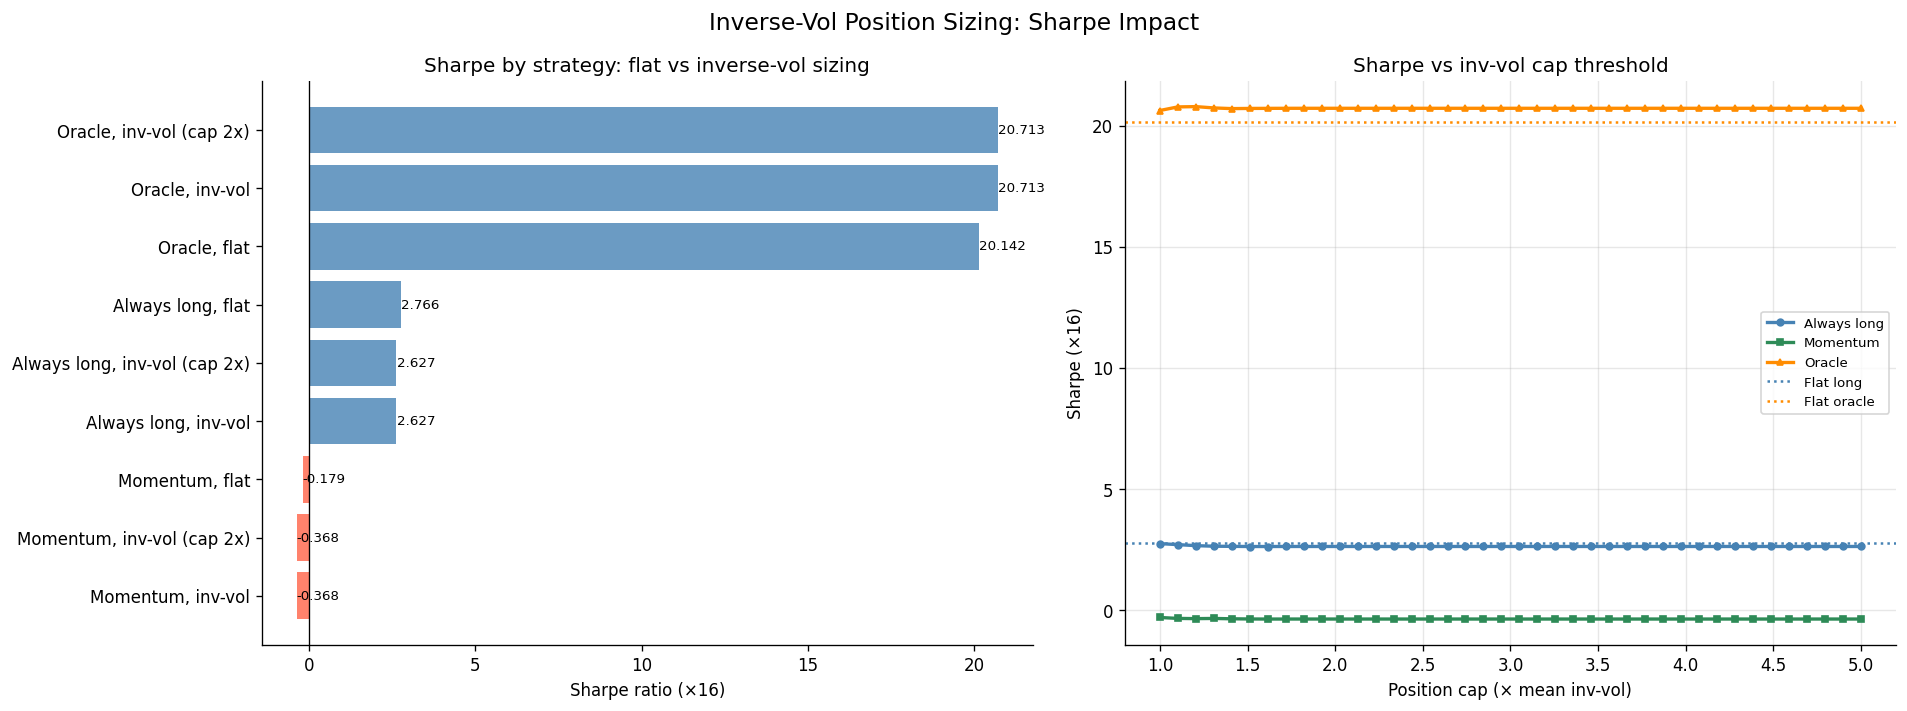

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar chart of Sharpe ratios
bar_colors = ['tomato' if v < 0 else 'steelblue' for v in sharpe_s.values]
axes[0].barh(sharpe_s.index, sharpe_s.values, color=bar_colors, alpha=0.8)
axes[0].axvline(0, color='k', lw=0.8)
for i, (name, val) in enumerate(sharpe_s.items()):
    axes[0].text(val + 0.01*np.sign(val), i, f'{val:.3f}', va='center', fontsize=8)
axes[0].set_xlabel('Sharpe ratio (×16)')
axes[0].set_title('Sharpe by strategy: flat vs inverse-vol sizing')

# 2. Sharpe vs cap threshold
caps = np.linspace(1.0, 5.0, 40)
sh_long   = [sharpe(np.clip(inv_vol_norm, 0, c), r2h) for c in caps]
sh_oracle = [sharpe(dir2h * np.clip(inv_vol_norm, 0, c), r2h) for c in caps]
sh_mom    = [sharpe(dir1h * np.clip(inv_vol_norm, 0, c), r2h) for c in caps]

axes[1].plot(caps, sh_long,   'o-', color='steelblue',  lw=2, ms=4, label='Always long')
axes[1].plot(caps, sh_mom,    's-', color='seagreen',   lw=2, ms=4, label='Momentum')
axes[1].plot(caps, sh_oracle, '^-', color='darkorange', lw=2, ms=4, label='Oracle')
axes[1].axhline(sharpe(np.ones(1000), r2h), color='steelblue', linestyle=':', lw=1.5, label='Flat long')
axes[1].axhline(sharpe(dir2h, r2h), color='darkorange',        linestyle=':', lw=1.5, label='Flat oracle')
axes[1].set_xlabel('Position cap (× mean inv-vol)')
axes[1].set_ylabel('Sharpe (×16)')
axes[1].set_title('Sharpe vs inv-vol cap threshold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('Inverse-Vol Position Sizing: Sharpe Impact', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Key Findings & Modelling Implications

| Finding | Implication |
|---------|-------------|
| 1st-half σ(bar ret) has a **moderate, statistically significant** correlation with \|return_2h\| (bootstrap CI well above zero) | Vol is a reliable magnitude signal — include as a feature |
| Vol persists: σ₁ and σ₂ are similarly correlated | A high-vol session stays high-vol; use vol estimate for sizing and uncertainty |
| Parkinson & Garman-Klass give similar r to close-to-close σ | GK vol is no worse, uses all OHLC info — use as an alternative feature |
| Recent-window vol (last 10–20 bars) is at least as predictive as full 50-bar vol | Weight recent bars more when estimating vol for sizing |
| Vol does **not** predict direction (r ≈ 0 for signed return_2h) | Vol is purely a sizing signal; direction model must be separate |
| High-vol regime has much higher P(\|ret\| > 2%) | Extreme sessions are the highest-stakes; vol-based sizing pays the most here |
| Inv-vol sizing improves Sharpe vs flat sizing **given any direction signal** | Correct direction + vol sizing is the double lever to optimise |
| Winsorising at ~2× mean is reasonable | Prevents extreme leverage from very-low-vol estimates |

### Next steps
1. Combine `vol_1h` (or GK estimate, last-20-bar window) with direction features in a gradient-boosted model
2. Train a dedicated vol-prediction model (ridge regression or GBM on bar-level features) to use as position scaler
3. Use vol regime as a conditioning variable — train separate direction models per regime
4. Evaluate vol-targeting on the public/private test sets after direction model is built